# Agricultural Drought Prediction using BiLSTM with ROS - Kansas

**Project:** Prediksi Kekeringan Pertanian menggunakan BiLSTM pada Data Satelit dan Label US Drought Monitor.

**Lokasi:** Kansas

**Pipeline:**
1. **EDA** — Exploratory Data Analysis
2. **Data Preprocessing** — Dekumulasi USDM, Temporal Split, Scaling
3. **Balancing (ROS)** — Adaptive Synthetic Sampling + Sliding Window
4. **BiLSTM Model** — dengan Focal Loss
5. **Evaluasi** — Classification Report (termasuk Macro F1), Confusion Matrix

**Metode Balancing:** ROS (Random Over Sampling)
- Lebih adaptif dari SMOTE: fokus menghasilkan sampel sintetis pada instance yang sulit dipelajari
- Dikombinasikan dengan Focal Loss untuk double protection pada minority class
- Menggunakan Sliding Window (seq_length=12) untuk menangkap pola musiman

## 1. Import Libraries & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import tensorflow as tf
from tensorflow.keras import backend as K, mixed_precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import os
import random
import psutil

mixed_precision.set_global_policy('mixed_float16')



# Configuration
DATA_PATH = 'Integrated_Kansas_Data.csv'
OUTPUT_FOLDER = 'output_ROS'
BATCH_SIZE = 32
EPOCHS = 200
SEQ_LENGTH = 12  # 12 bulan = 1 siklus tahunan
TRAIN_END_YEAR = 2021  # Train: 2014-2021, Test: 2022-2024

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
SEED = 42

# Set seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")
p = psutil.Process(os.getpid())
p.cpu_affinity(list(range(12))) 

print(f"Berhasil mengunci proses ke P-Cores: {p.cpu_affinity()}")

Libraries imported successfully.
TensorFlow version: 2.21.0
Berhasil mengunci proses ke P-Cores: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 2. Exploratory Data Analysis (EDA)

### 2.1 Load & Inspect Data

In [2]:
df = pd.read_csv(DATA_PATH)

# Parse date columns
df['Year'] = df['YearMonth'].astype(str).str[:4].astype(int)
df['Month'] = df['YearMonth'].astype(str).str[4:6].astype(int)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values(by=['FIPS', 'Date']).reset_index(drop=True)

print(f"Data loaded. Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of counties: {df['FIPS'].nunique()}")
print(f"Number of months: {df['YearMonth'].nunique()}")
df.head()

Data loaded. Shape: (2640, 21)
Date range: 2014-01-01 00:00:00 to 2024-12-01 00:00:00
Number of counties: 20
Number of months: 132


,YearMonth,State,FIPS,County,None,D0,D1,D2,D3,D4,...,PRECTOTCORR,PS,RH2M,T2M,WS2M,Latitude,Longitude,Year,Month,Date
0,201401,KS,20009,Barton County,0.0,100.0,100.00,24.25,0.000,0.0,...,0.13,95.16,60.95,-1.31,4.07,38.3645,-98.7648,2014,1,2014-01-01
1,201402,KS,20009,Barton County,0.0,100.0,99.79,70.45,0.000,0.0,...,0.49,95.14,65.86,-1.84,3.63,38.3645,-98.7648,2014,2,2014-02-01
2,201403,KS,20009,Barton County,0.0,100.0,99.79,61.60,0.000,0.0,...,0.22,94.94,55.04,4.44,4.45,38.3645,-98.7648,2014,3,2014-03-01
3,201404,KS,20009,Barton County,0.0,100.0,100.00,100.00,6.534,0.0,...,0.84,94.53,52.63,12.48,4.75,38.3645,-98.7648,2014,4,2014-04-01
4,201405,KS,20009,Barton County,0.0,100.0,100.00,100.00,100.000,0.0,...,1.82,94.64,55.37,19.78,3.21,38.3645,-98.7648,2014,5,2014-05-01


In [3]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
YearMonth            0
State                0
FIPS                 0
County               0
None                 0
D0                   0
D1                   0
D2                   0
D3                   0
D4                   0
ALLSKY_SFC_SW_DWN    0
PRECTOTCORR          0
PS                   0
RH2M                 0
T2M                  0
WS2M                 0
Latitude             0
Longitude            0
Year                 0
Month                0
Date                 0
dtype: int64

Data Types:
YearMonth                     int64
State                           str
FIPS                          int64
County                          str
None                        float64
D0                          float64
D1                          float64
D2                          float64
D3                          float64
D4                          float64
ALLSKY_SFC_SW_DWN           float64
PRECTOTCORR                 float64
PS                          float64
RH2M   

### 2.2 Descriptive Statistics

In [4]:
feature_cols = ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M']
drought_cols = ['None', 'D0', 'D1', 'D2', 'D3', 'D4']

print("Descriptive Statistics (Weather Features):")
display(df[feature_cols].describe())

print("\nDescriptive Statistics (Drought Percentages):")
display(df[drought_cols].describe())

Descriptive Statistics (Weather Features):


,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,WS2M
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,16.644091,2.106451,95.176682,64.702731,13.443114,3.355432
std,6.054130,1.818803,2.859697,10.245257,10.034634,0.521531
min,5.050000,0.000000,88.340000,35.050000,-6.290000,1.730000
25%,10.800000,0.690000,92.530000,56.997500,4.160000,3.040000
50%,17.140000,1.630000,96.470000,64.605000,13.555000,3.340000
75%,22.080000,3.050000,97.440000,72.500000,23.682500,3.710000
max,28.410000,12.930000,99.030000,88.950000,31.100000,4.870000



Descriptive Statistics (Drought Percentages):


,None,D0,D1,D2,D3,D4
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,44.091148,55.908852,34.625189,17.277637,7.700863,2.185608
std,44.510979,44.510979,42.870992,33.990296,23.705107,12.933503
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.946250,73.053750,0.270000,0.000000,0.000000,0.000000
75%,100.000000,100.000000,87.645000,6.133125,0.000000,0.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


### 2.3 Correlation Heatmap

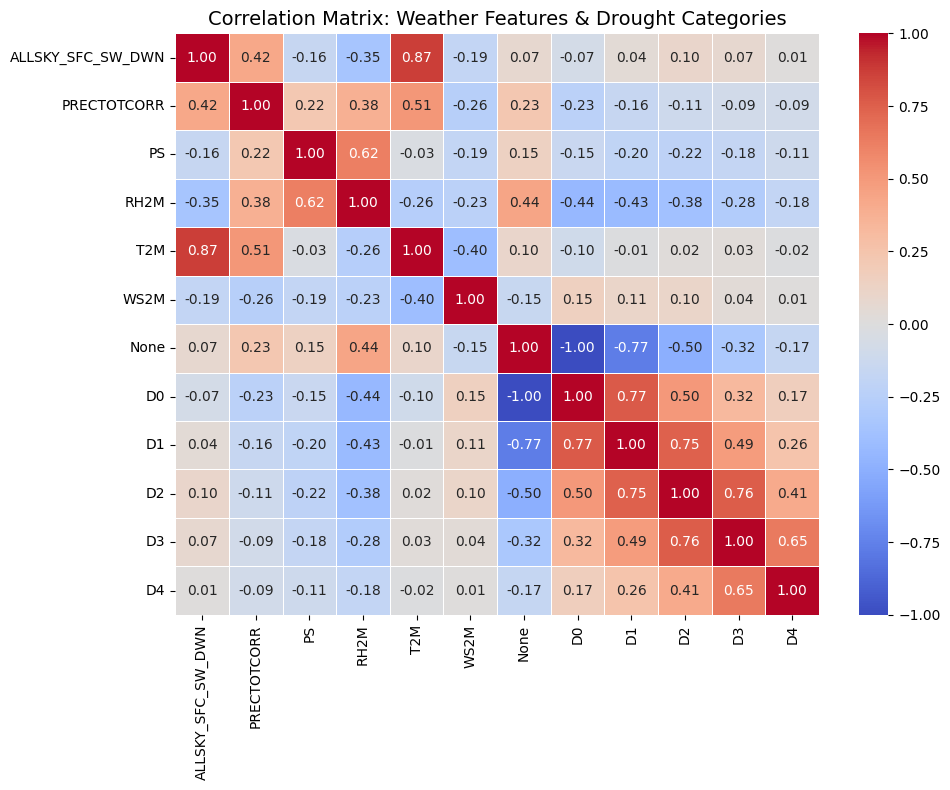

Saved plot to output_ROS/ROS_Kansas_correlation.png


In [5]:
plt.figure(figsize=(10, 8))
corr_data = df[feature_cols + drought_cols].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Weather Features & Drought Categories', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_correlation.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_correlation.png')

### 2.4 Time Series Visualization

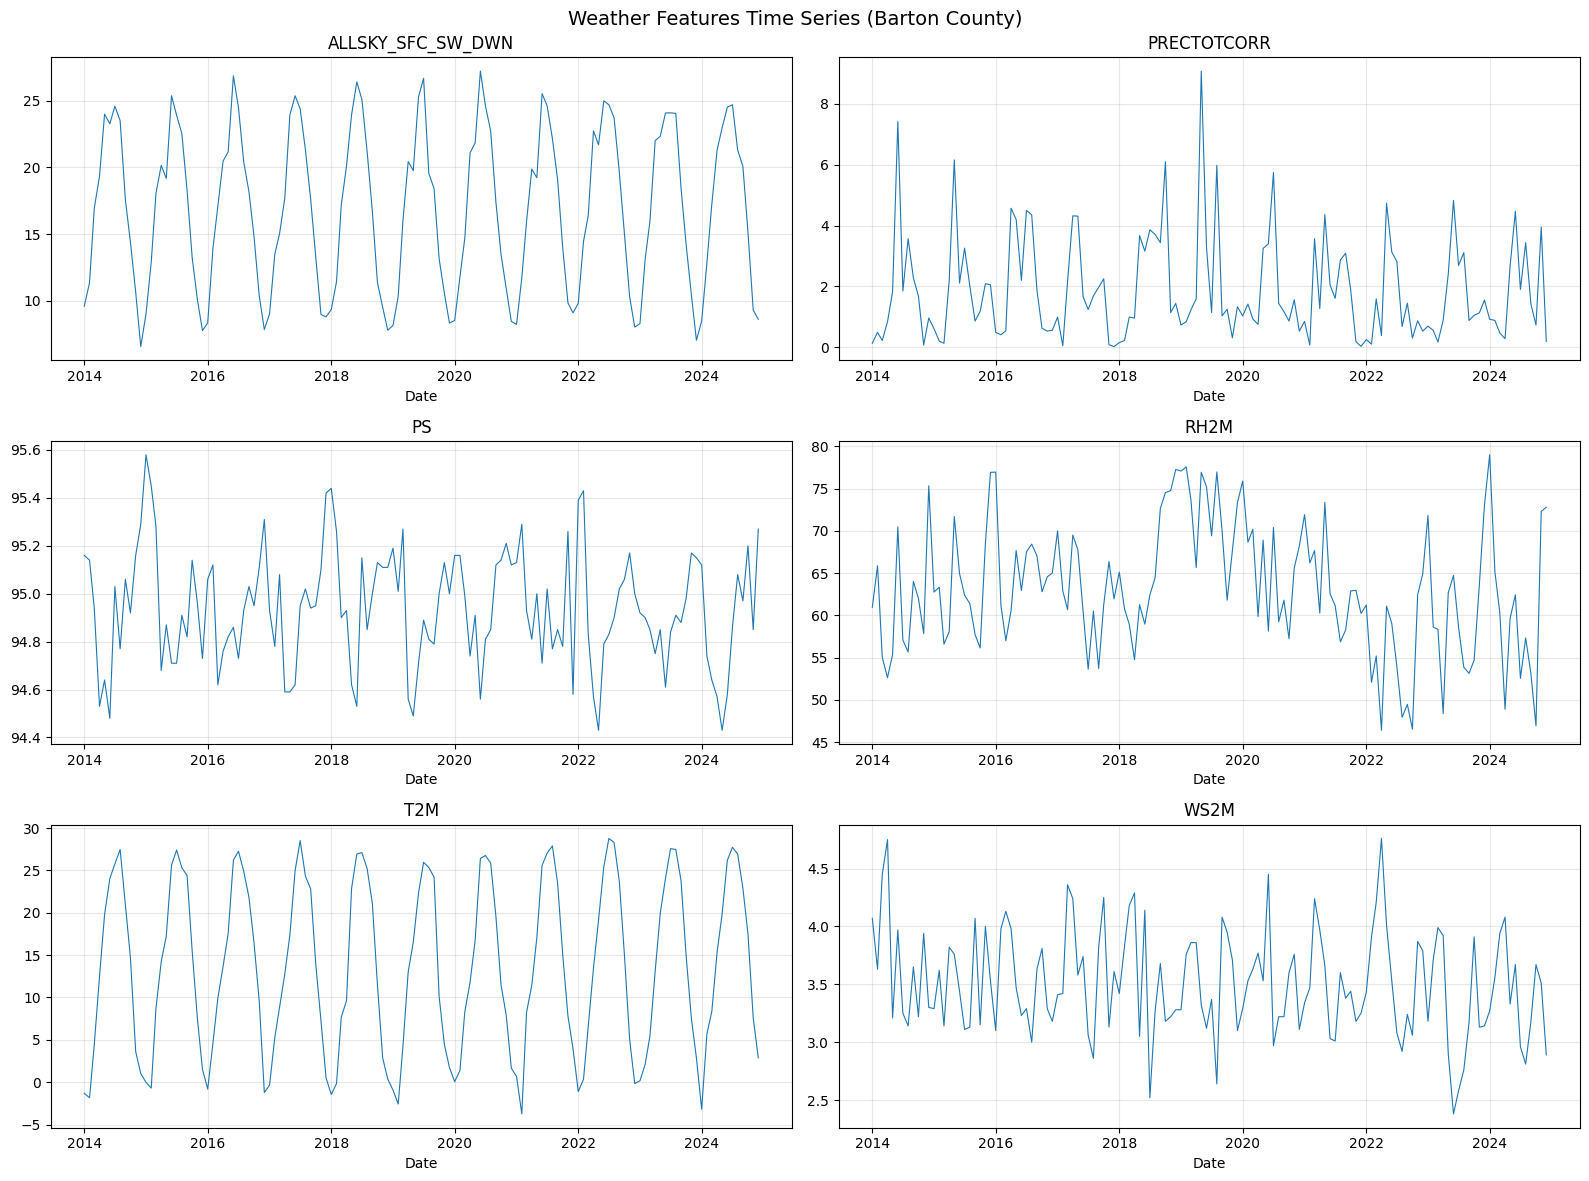

Saved plot to output_ROS/ROS_Kansas_timeseries.png


In [6]:
# Time series of weather features for a sample county
sample_county = df['County'].unique()[0]
subset = df[df['County'] == sample_county]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(f'Weather Features Time Series ({sample_county})', fontsize=14)

for idx, col in enumerate(feature_cols):
    ax = axes[idx // 2, idx % 2]
    ax.plot(subset['Date'], subset[col], linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('Date')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_timeseries.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_timeseries.png')

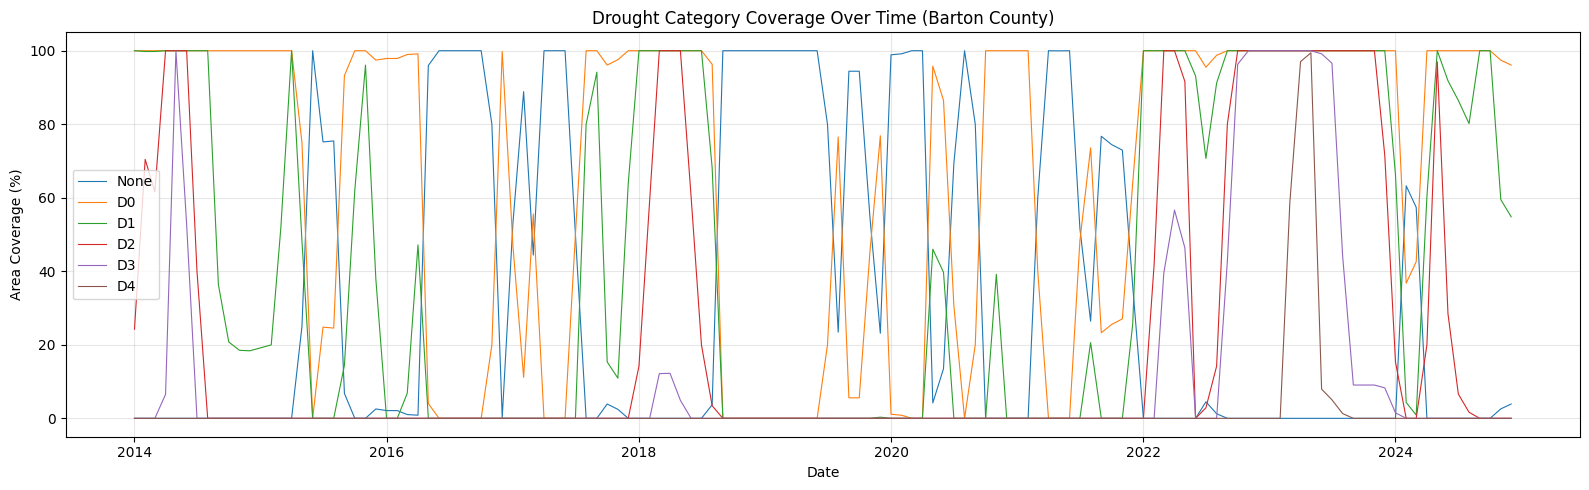

Saved plot to output_ROS/ROS_Kansas_drought_timeseries.png


In [7]:
# Drought categories over time for sample county
fig, ax = plt.subplots(figsize=(16, 5))
for col in drought_cols:
    ax.plot(subset['Date'], subset[col], label=col, linewidth=0.8)
ax.set_title(f'Drought Category Coverage Over Time ({sample_county})')
ax.set_xlabel('Date')
ax.set_ylabel('Area Coverage (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_drought_timeseries.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_drought_timeseries.png')

## 3. Data Preprocessing

### 3.1 Transformasi Dekumulatif (CDF → PMF)
Data US Drought Monitor bersifat kumulatif (D0 mencakup D1-D4).
Kita ubah menjadi Probability Mass Function (PMF) agar saling lepas (mutually exclusive).

In [8]:
def decumulate_drought(row):
    """Convert cumulative drought percentages to mutually exclusive PMF."""
    pmf_d4 = row['D4']
    pmf_d3 = max(0, row['D3'] - row['D4'])
    pmf_d2 = max(0, row['D2'] - row['D3'])
    pmf_d1 = max(0, row['D1'] - row['D2'])
    pmf_d0 = max(0, row['D0'] - row['D1'])
    pmf_none = row['None']
    
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
df[pmf_cols] = df.apply(decumulate_drought, axis=1)

# Validate: sum should be ~100
df['PMF_Sum'] = df[pmf_cols].sum(axis=1)
print("PMF Sum Stats (should be ~100):")
print(df['PMF_Sum'].describe())

PMF Sum Stats (should be ~100):
count    2.640000e+03
mean     1.000000e+02
std      2.766308e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: PMF_Sum, dtype: float64


### 3.2 Penentuan Label Kelas
Menggunakan kelas dominan (persentase area tertinggi).

Class Distribution (Before Balancing):
  None (class 0):  1208 (45.8%)
    D0 (class 1):   502 (19.0%)
    D1 (class 2):   477 (18.1%)
    D2 (class 3):   250 (9.5%)
    D3 (class 4):   144 (5.5%)
    D4 (class 5):    59 (2.2%)

Total samples: 2640
Imbalance ratio (max/min): 20.5x


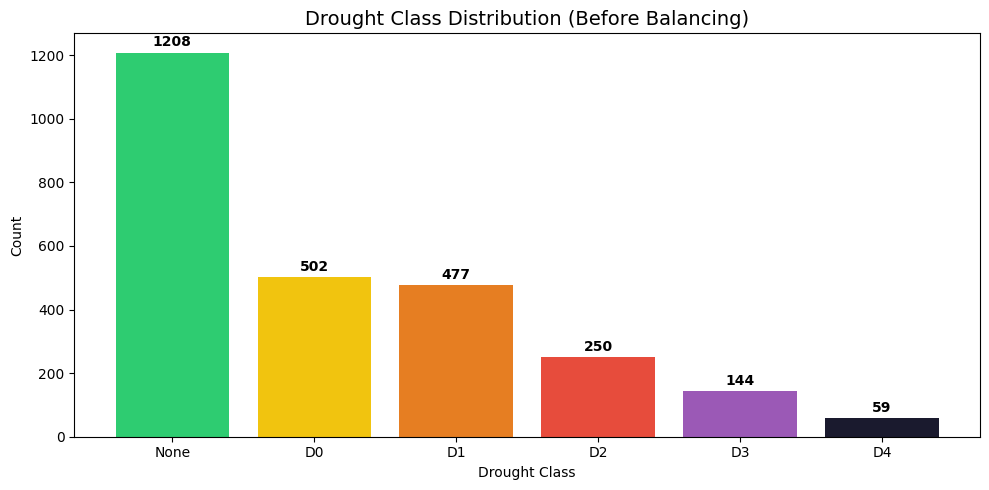

Saved plot to output_ROS/ROS_Kansas_class_distribution.png


In [9]:
df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

print("Class Distribution (Before Balancing):")
class_dist = df['Label'].value_counts().sort_index()
for idx, count in class_dist.items():
    pct = count / len(df) * 100
    print(f"  {label_map[idx]:>4s} (class {idx}): {count:>5d} ({pct:.1f}%)")

print(f"\nTotal samples: {len(df)}")
print(f"Imbalance ratio (max/min): {class_dist.max()/class_dist.min():.1f}x")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([label_map[i] for i in range(6)], [class_dist.get(i, 0) for i in range(6)],
              color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#1a1a2e'])
ax.set_title('Drought Class Distribution (Before Balancing)', fontsize=14)
ax.set_xlabel('Drought Class')
ax.set_ylabel('Count')
for bar, count in zip(bars, [class_dist.get(i, 0) for i in range(6)]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_class_distribution.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_class_distribution.png')

### 3.3 Temporal Train/Test Split
Menggunakan temporal split untuk mencegah data leakage:
- **Train:** 2014 – 2021
- **Test:** 2022 – 2024

In [10]:
train_df = df[df['Year'] <= TRAIN_END_YEAR].copy()
test_df = df[df['Year'] > TRAIN_END_YEAR].copy()

print(f"Train set: {train_df.shape[0]} rows (Years: {sorted(train_df['Year'].unique())})")
print(f"Test set:  {test_df.shape[0]} rows (Years: {sorted(test_df['Year'].unique())})")

print(f"\nTrain class distribution:")
train_dist = train_df['Label'].value_counts().sort_index()
for idx, count in train_dist.items():
    print(f"  {label_map[idx]:>4s}: {count}")

print(f"\nTest class distribution:")
test_dist = test_df['Label'].value_counts().sort_index()
for idx, count in test_dist.items():
    print(f"  {label_map[idx]:>4s}: {count}")

Train set: 1920 rows (Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)])
Test set:  720 rows (Years: [np.int64(2022), np.int64(2023), np.int64(2024)])

Train class distribution:
  None: 1070
    D0: 368
    D1: 289
    D2: 136
    D3: 55
    D4: 2

Test class distribution:
  None: 138
    D0: 134
    D1: 188
    D2: 114
    D3: 89
    D4: 57


### 3.4 Feature Scaling (No Leakage)
MinMaxScaler di-fit HANYA pada training data, lalu diterapkan ke test data.

In [11]:
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

train_df.loc[:, feature_cols] = scaler.transform(train_df[feature_cols])
test_df.loc[:, feature_cols] = scaler.transform(test_df[feature_cols])

print("Scaled Features Sample (Train):")
print(train_df[feature_cols].head())
print(f"\nTrain feature range: [{train_df[feature_cols].min().min():.4f}, {train_df[feature_cols].max().max():.4f}]")

Scaled Features Sample (Train):
   ALLSKY_SFC_SW_DWN  PRECTOTCORR        PS      RH2M       T2M      WS2M
0           0.194349     0.010054  0.637979  0.451573  0.139809  0.745223
1           0.270120     0.037896  0.636109  0.551900  0.124930  0.605096
2           0.508562     0.017015  0.617399  0.330813  0.301235  0.866242
3           0.611729     0.064965  0.579046  0.281569  0.526951  0.961783
4           0.810788     0.140758  0.589336  0.337556  0.731892  0.471338

Train feature range: [0.0000, 1.0000]


### 3.5 Feature Engineering - Tambah Lag, Rolling, dan Seasonal Features

In [12]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df_fe = df.copy()
df_fe = df_fe.sort_values(by=['FIPS', 'Date']).reset_index(drop=True)

# 1. Lag Features
for lag in [1, 2, 3, 6]:
    df_fe[f'PREC_lag{lag}'] = df_fe.groupby('FIPS')['PRECTOTCORR'].shift(lag)
    df_fe[f'T2M_lag{lag}']  = df_fe.groupby('FIPS')['T2M'].shift(lag)

# 2. Rolling Statistics
for window in [3, 6]:
    df_fe[f'PREC_roll{window}_mean'] = df_fe.groupby('FIPS')['PRECTOTCORR'] \
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    df_fe[f'PREC_roll{window}_std']  = df_fe.groupby('FIPS')['PRECTOTCORR'] \
        .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    df_fe[f'T2M_roll{window}_mean']  = df_fe.groupby('FIPS')['T2M'] \
        .transform(lambda x: x.rolling(window, min_periods=1).mean())

# 3. Seasonal Encoding
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)

# 4. Precipitation Anomaly
monthly_mean = df_fe.groupby(['FIPS', 'Month'])['PRECTOTCORR'].transform('mean')
df_fe['PREC_anomaly'] = df_fe['PRECTOTCORR'] - monthly_mean

# 5. SPI Proxy (deficit 3 bulan vs long-term mean)
rolling_3 = df_fe.groupby('FIPS')['PRECTOTCORR'] \
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
long_term = df_fe.groupby('FIPS')['PRECTOTCORR'].transform('mean')
df_fe['PREC_deficit_3m'] = rolling_3 - long_term

# 6. Heat-Dry Stress Index
df_fe['heat_dry_stress'] = df_fe['T2M'] * (1 - df_fe['RH2M'] / 100)

# 7. Drought Carry-over
df_fe['drought_carryover'] = df_fe['D1'] + 0.5 * df_fe['D2']

# 8. D2 Moderate Deficit Signal
df_fe['PREC_moderate_deficit'] = np.where(
    (df_fe['PRECTOTCORR'] > 0) & (df_fe['PRECTOTCORR'] < 1.0),
    1.0, 0.0
)

# 9.D4 Extreme Drought Signal (ekstrem kering)
df_fe['extreme_dry'] = np.where(
    (df_fe['PRECTOTCORR'] < 0.1) & (df_fe['T2M'] > df_fe.groupby('FIPS')['T2M'].transform('mean') + 5),
    1.0, 0.0
)
# D4 severity cumulative
df_fe['severe_carryover'] = df_fe['D3'] + df_fe['D4']  # D3+D4 bulan lalu


# Drop NaN dari lag features
df_fe = df_fe.dropna().reset_index(drop=True)

# Definisi feature_cols FINAL
feature_cols = [
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M',
    'PREC_lag1', 'PREC_lag2', 'PREC_lag3', 'PREC_lag6',
    'T2M_lag1',  'T2M_lag2',  'T2M_lag3',  'T2M_lag6',
    'PREC_roll3_mean', 'PREC_roll3_std', 'PREC_roll6_mean', 'PREC_roll6_std',
    'T2M_roll3_mean',  'T2M_roll6_mean',
    'month_sin', 'month_cos',
    'PREC_anomaly',
    'PREC_deficit_3m',
    'heat_dry_stress',
    'drought_carryover',
    'PREC_moderate_deficit',
    'extreme_dry', 'severe_carryover'
]

df = df_fe

print(f"Jumlah fitur: {len(feature_cols)}")   # 27
print(f"Data shape  : {df.shape}")
print(f"Semua ada di df? {all(c in df.columns for c in feature_cols)}")


Jumlah fitur: 29
Data shape  : (2520, 52)
Semua ada di df? True


In [13]:

# ============================================================
# RE-SPLIT TRAIN/TEST AFTER FEATURE ENGINEERING
# ============================================================

train_df = df[df['Year'] <= TRAIN_END_YEAR].copy()
test_df = df[df['Year'] > TRAIN_END_YEAR].copy()

print(f"Re-split after FE:")
print(f"Train set: {train_df.shape[0]} rows (Years: {sorted(train_df['Year'].unique())})")
print(f"Test set:  {test_df.shape[0]} rows (Years: {sorted(test_df['Year'].unique())})")

print(f"\nTrain class distribution:")
train_dist = train_df['Label'].value_counts().sort_index()
for idx, count in train_dist.items():
    print(f"  {label_map[idx]:>4s}: {count}")

print(f"\nTest class distribution:")
test_dist = test_df['Label'].value_counts().sort_index()
for idx, count in test_dist.items():
    print(f"  {label_map[idx]:>4s}: {count}")


Re-split after FE:
Train set: 1800 rows (Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)])
Test set:  720 rows (Years: [np.int64(2022), np.int64(2023), np.int64(2024)])

Train class distribution:
  None: 1068
    D0: 340
    D1: 262
    D2: 97
    D3: 31
    D4: 2

Test class distribution:
  None: 138
    D0: 134
    D1: 188
    D2: 114
    D3: 89
    D4: 57


## 4. Balancing RandomOverSampler

### 4.1 Apply ROS pada Data Training

**Mengapa ROS?**
- ROS (Random Over Sampling) menduplikasi sampel secara acak dari kelas minoritas untuk menyeimbangkan distribusi data.\n
- ROS merupakan metode yang sederhana dan efektif untuk masalah imbalanced class ekstrem tanpa menambahkan data buatan (sintetis).\n
- Cocok untuk kasus kita dimana batas antara level kekeringan D0-D4 seringkali kabur.

**Strategi:** ROS diterapkan pada data 2D (sebelum sliding window) karena ROS membutuhkan input flat features.

Before ROS: Counter({np.int64(0): 1068, np.int64(1): 340, np.int64(2): 262, np.int64(3): 97, np.int64(4): 31, np.int64(5): 2})
Total train samples: 1800

After ROS: Counter({np.int64(2): 1068, np.int64(1): 1068, np.int64(0): 1068, np.int64(3): 1068, np.int64(4): 1068, np.int64(5): 1068})
Total resampled samples: 6408


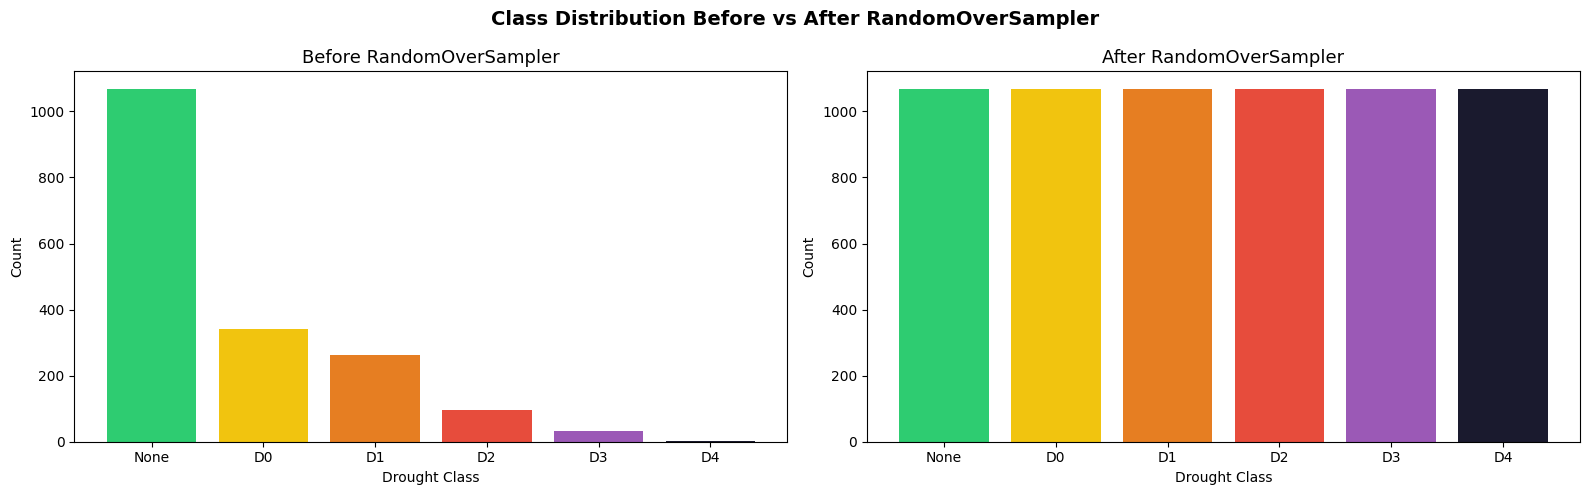

In [14]:
# Prepare 2D training data
X_train_2d = train_df[feature_cols].values
y_train_flat = train_df['Label'].values

print(f"Before ROS: {Counter(y_train_flat)}")
print(f"Total train samples: {len(y_train_flat)}")

# ✅ RandomOverSampler — tidak ada error meski D4 hanya 2 samples
ros = RandomOverSampler(
    sampling_strategy='auto',   # oversample semua kelas ke level majority
    random_state=42
)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_2d, y_train_flat)

print(f"\nAfter ROS: {Counter(y_train_resampled)}")
print(f"Total resampled samples: {len(y_train_resampled)}")

# Visualize class distribution after ROS
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
before_counts = Counter(y_train_flat)
axes[0].bar([label_map[i] for i in range(6)], [before_counts.get(i, 0) for i in range(6)],
            color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#9b59b6','#1a1a2e'])
axes[0].set_title('Before RandomOverSampler', fontsize=13)
axes[0].set_xlabel('Drought Class')
axes[0].set_ylabel('Count')

# After
after_counts = Counter(y_train_resampled)
axes[1].bar([label_map[i] for i in range(6)], [after_counts.get(i, 0) for i in range(6)],
            color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#9b59b6','#1a1a2e'])
axes[1].set_title('After RandomOverSampler', fontsize=13)
axes[1].set_xlabel('Drought Class')
axes[1].set_ylabel('Count')

fig.suptitle('Class Distribution Before vs After RandomOverSampler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_balance_comparison.png', dpi=150)
plt.show()


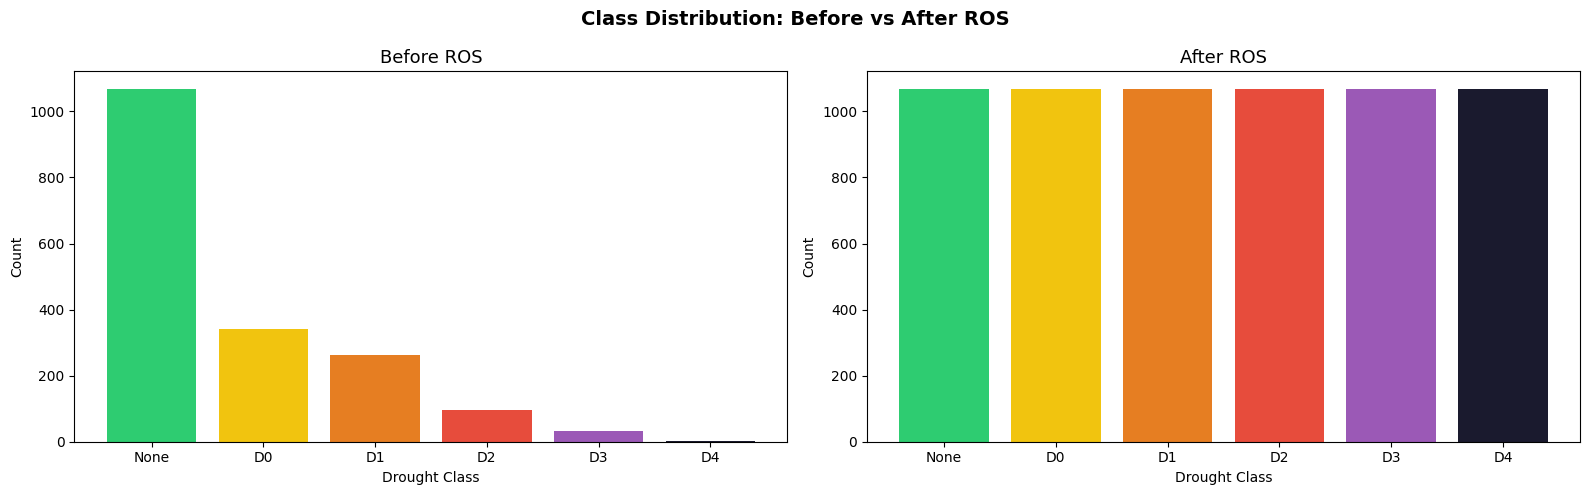

Saved plot to output_ROS/ROS_Kansas_balance_comparison.png


In [15]:
# Visualize class distribution after ROS
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
before_counts = Counter(y_train_flat)
axes[0].bar([label_map[i] for i in range(6)], [before_counts.get(i, 0) for i in range(6)],
            color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#1a1a2e'])
axes[0].set_title('Before ROS', fontsize=13)
axes[0].set_xlabel('Drought Class')
axes[0].set_ylabel('Count')

# After
after_counts = Counter(y_train_resampled)
axes[1].bar([label_map[i] for i in range(6)], [after_counts.get(i, 0) for i in range(6)],
            color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#1a1a2e'])
axes[1].set_title('After ROS', fontsize=13)
axes[1].set_xlabel('Drought Class')
axes[1].set_ylabel('Count')

fig.suptitle('Class Distribution: Before vs After ROS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_balance_comparison.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_balance_comparison.png')

### 4.2 Sliding Window Preprocessing

**Sequence Length = 12 bulan**
- Data bulanan → window 12 bulan mencakup satu siklus tahunan penuh
- Model dapat mempelajari pola musiman (seasonality)

**Catatan:** Sliding window diterapkan pada data yang sudah di-resample (ROS).
Karena data ROS tidak memiliki temporal order, kita buat pseudo-sequences dengan reshaping.
Untuk test data, kita gunakan sliding window asli per county (FIPS) dengan temporal ordering.

In [16]:
def create_sequences_from_df(df, feature_cols, label_col, seq_length=12, id_col='FIPS'):
    """
    Create sliding window sequences from DataFrame, grouped by location.
    Prevents spatial leakage by grouping per FIPS.
    """
    X, y = [], []
    
    for fips, group in df.groupby(id_col):
        group = group.sort_values('Date')
        feats = group[feature_cols].values
        labels = group[label_col].values
        
        if len(group) < seq_length:
            continue
            
        for i in range(len(group) - seq_length + 1):
            window = feats[i : i + seq_length]
            target = labels[i + seq_length - 1]
            X.append(window)
            y.append(target)
            
    return np.array(X), np.array(y)

# Create test sequences using proper temporal sliding window
X_test, y_test = create_sequences_from_df(test_df, feature_cols, 'Label', SEQ_LENGTH)

print(f"X_test shape: {X_test.shape}")
print(f"y_test distribution: {Counter(y_test)}")

X_test shape: (500, 12, 29)
y_test distribution: Counter({np.int64(2): 143, np.int64(1): 102, np.int64(0): 93, np.int64(3): 74, np.int64(4): 52, np.int64(5): 36})


In [17]:
# Step 1: Create sequences from original training data
X_train_seq, y_train_seq = create_sequences_from_df(train_df, feature_cols, 'Label', SEQ_LENGTH)
print(f"Train sequences (before ROS): {X_train_seq.shape}")
print(f"y_train_seq distribution: {Counter(y_train_seq)}")

# Step 2: Flatten sequences 3D → 2D
n_samples, n_timesteps, n_features = X_train_seq.shape
X_train_flat = X_train_seq.reshape(n_samples, n_timesteps * n_features)
print(f"\nFlattened for ROS: {X_train_flat.shape}")

# ✅ Step 3: Custom sampling strategy (ganti ros_seq yang lama)
dist = Counter(y_train_seq)
majority_count = max(dist.values())
max_target = int(majority_count * 0.8)

sampling_strategy = {}
for cls, count in dist.items():
    if count < max_target:
        sampling_strategy[cls] = max_target
    else:
        sampling_strategy[cls] = count

print("\nSampling strategy:", sampling_strategy)
#for cls, count in custom_strategy.items():
 #   print(f"  Class {cls} ({label_map[cls]}): {count} samples")

ros_seq = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=SEED
)
X_train_ros_flat, y_train_ros = ros_seq.fit_resample(X_train_flat, y_train_seq)

print(f"\nAfter resampling: {Counter(y_train_ros)}")
print(f"Total resampled sequences: {len(y_train_ros)}")

# Step 4: Reshape back to 3D
X_train_final = X_train_ros_flat.reshape(-1, n_timesteps, n_features)
print(f"\nFinal X_train shape: {X_train_final.shape}")
print(f"Final X_test shape: {X_test.shape}")


Train sequences (before ROS): (1580, 12, 29)
y_train_seq distribution: Counter({np.int64(0): 1028, np.int64(1): 274, np.int64(2): 177, np.int64(3): 72, np.int64(4): 27, np.int64(5): 2})

Flattened for ROS: (1580, 348)

Sampling strategy: {np.int64(0): 1028, np.int64(1): 822, np.int64(2): 822, np.int64(3): 822, np.int64(4): 822, np.int64(5): 822}

After resampling: Counter({np.int64(0): 1028, np.int64(1): 822, np.int64(2): 822, np.int64(3): 822, np.int64(4): 822, np.int64(5): 822})
Total resampled sequences: 5138

Final X_train shape: (5138, 12, 29)
Final X_test shape: (500, 12, 29)


In [18]:
num_classes = 6
# ✅ Ganti y_train_ros → y_train_ros
y_train_encoded = to_categorical(y_train_ros, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print(f"y_train_encoded shape: {y_train_encoded.shape}")
print(f"y_test_encoded shape: {y_test_encoded.shape}")


y_train_encoded shape: (5138, 6)
y_test_encoded shape: (500, 6)


## 5. BiLSTM Model

### 5.1 Focal Loss Implementation
Focal Loss memberikan bobot lebih tinggi pada sampel yang sulit diklasifikasikan, dikombinasikan dengan class weights untuk double protection.

In [19]:
def categorical_focal_loss(gamma=2.0, alpha=None):
    """
    Categorical focal loss.
    - gamma: focusing parameter (mengurangi bobot easy examples)
    - alpha: per-class weight tensor, shape (num_classes,)
             index 0 = None, 1 = D0, ..., 5 = D4
    """
    def focal_loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred  = K.clip(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * K.log(y_pred)           # (batch, num_classes)
        focal_weight  = K.pow(1.0 - y_pred, gamma)        # (batch, num_classes)
        loss          = focal_weight * cross_entropy       # (batch, num_classes)

        # ✅ Alpha diaplikasikan di sini (bukan hanya dideklarasikan)
        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)  # (num_classes,)
            loss = alpha_tensor * loss                            # broadcast ke (batch, num_classes)

        return K.sum(loss, axis=-1)                        # (batch,)
    return focal_loss


# ✅ Alpha per kelas — None (index 0) diberi bobot lebih besar
# Total tidak harus = 1, tapi proporsinya yang penting.
# Kalau None F1 masih rendah setelah run, coba naikkan alpha[0] ke 0.45
FOCAL_ALPHA       = [0.22, 0.35, 0.13, 0.12, 0.10, 0.08]  # [None, D0, D1, D2, D3, D4]

num_classes = 6  # atau len(label_map) kalau dinamis
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train_seq
)

# Normalisasi supaya rata-rata = 1
class_weights_array = class_weights_array / class_weights_array.mean()

# --- BOOST NONE ---
# None (index 0) dapat bobot rendah karena dia majority class.
# Kita set manual ke rata-rata bobot kelas drought (index 1-5) × 2.0
none_boost_factor = 1.1
class_weights_array[0] = class_weights_array[1:].mean() * none_boost_factor

class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights (after None boost):")
for i, w in class_weight_dict.items():
    print(f"  {label_map[i]:>4s}: {w:.4f}") 


Class weights (after None boost):
  None: 1.3177
    D0: 0.0390
    D1: 0.0604
    D2: 0.1485
    D3: 0.3960
    D4: 5.3457


### 5.2 Build BiLSTM Model

In [20]:
def build_bilstm_model(seq_length, n_features, num_classes):
    """Build a 3-layer BiLSTM model with BatchNorm and Dropout."""
    model = Sequential([
        Input(shape=(seq_length, n_features)),

        # Layer 1: BiLSTM 128 units
        Bidirectional(LSTM(128, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.4),

        # Layer 2: BiLSTM 64 units
        Bidirectional(LSTM(64, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.4),

        # Layer 3: BiLSTM 32 units
        Bidirectional(LSTM(32)),
        BatchNormalization(),
        Dropout(0.4),

        # Dense layers
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=categorical_focal_loss(gamma=2.0, alpha=FOCAL_ALPHA),  # ✅ alpha aktif
        metrics=['accuracy']
    )

    return model

model = build_bilstm_model(SEQ_LENGTH, n_features, num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 256)        │       161,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 12, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 375,590 (1.43 MB)

 Trainable params: 374,694 (1.43 MB)

 Non-trainable params: 896 (3.50 KB)

### 5.3 Training

In [21]:
from sklearn.model_selection import train_test_split
# Compute sample weights for training (additional class weighting during training)
sample_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
sample_weights = np.array([sample_weight_dict[y] for y in y_train_ros])
print(f"Sample weights range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=40,              # ← naik dari default (~5) ke 20
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        f'{OUTPUT_FOLDER}/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,               # ← turunkan LR setelah 8 epoch stagnan
        min_lr=1e-6,
        verbose=1
    )
]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_ros   # pastikan distribusi kelas seimbang di val
)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")

print("\nStarting training...")
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    #class_weight=class_weight_dict,
    callbacks=callbacks,
    #shuffle=False,
    verbose=1
)

print("\nTraining completed!")

Sample weights range: [0.0390, 5.3457]
Train: (4110, 12, 29), Val: (1028, 12, 29)

Starting training...
Epoch 1/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.5178 - loss: 0.1079 - val_accuracy: 0.6936 - val_loss: 0.0659 - learning_rate: 0.0010
Epoch 2/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7095 - loss: 0.0499 - val_accuracy: 0.8181 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 3/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7616 - loss: 0.0374 - val_accuracy: 0.8648 - val_loss: 0.0199 - learning_rate: 0.0010
Epoch 4/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7866 - loss: 0.0315 - val_accuracy: 0.8716 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 5/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8071 - loss: 0.0290 - val_accuracy: 0.8920 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 6/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8345 - loss: 0.0250 - val_accuracy: 0.8940 - val_loss: 0.

## 6. Evaluasi

### 6.1 Training History

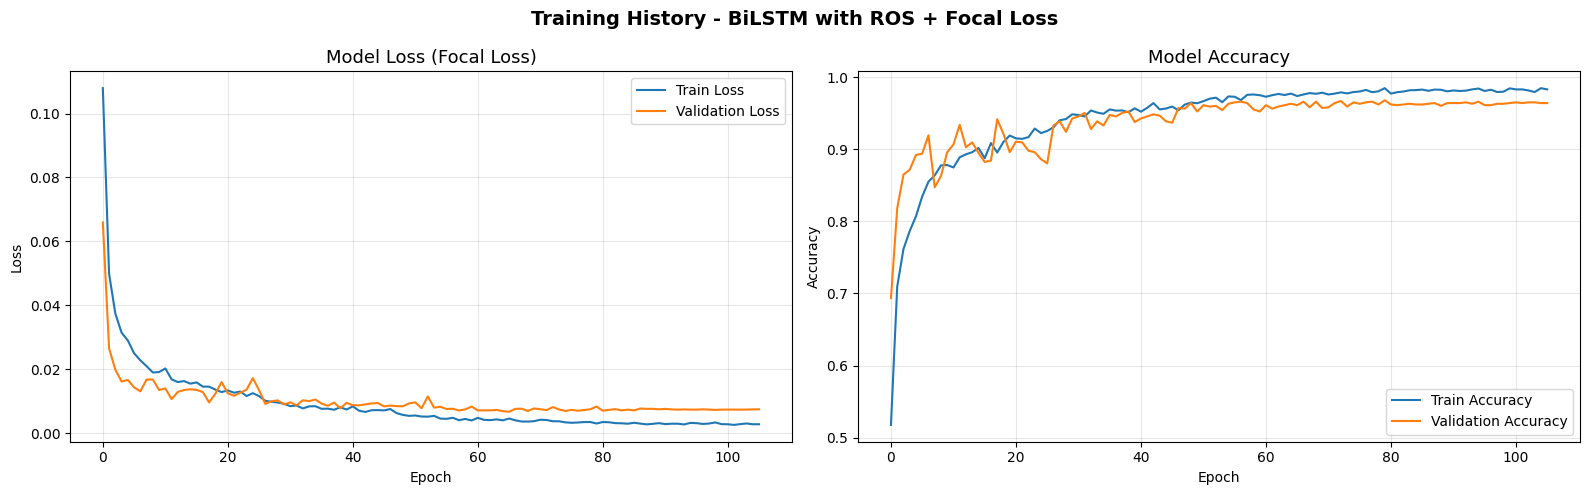

Saved plot to output_ROS/ROS_Kansas_training_history.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=1.5)
axes[0].set_title('Model Loss (Focal Loss)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=1.5)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=1.5)
axes[1].set_title('Model Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Training History - BiLSTM with ROS + Focal Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_training_history.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_training_history.png')

### 6.2 Prediction & Classification Report

In [23]:
# Predict
print("Predicting on test set...")
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Get unique classes present in test data
present_classes = sorted(set(y_test) | set(y_pred))
target_names = [label_map[i] for i in present_classes]

# Classification Report
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
report = classification_report(
    y_test, y_pred,
    labels=present_classes,
    target_names=target_names,
    digits=4,
    zero_division=0
)
print(report)

# Key Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("="*60)
print("KEY METRICS")
print("="*60)
print(f"Accuracy:     {accuracy:.4f}")
print(f"Macro F1:     {macro_f1:.4f}")
print(f"Weighted F1:  {weighted_f1:.4f}")
print("="*60)

Predicting on test set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

        None     0.7867    0.6344    0.7024        93
          D0     0.6518    0.7157    0.6822       102
          D1     0.8067    0.8462    0.8259       143
          D2     0.6747    0.7568    0.7134        74
          D3     0.9318    0.7885    0.8542        52
          D4     0.9444    0.9444    0.9444        36

    accuracy                         0.7680       500
   macro avg     0.7993    0.7810    0.7871       500
weighted avg     0.7748    0.7680    0.7685       500

KEY METRICS
Accuracy:     0.7680
Macro F1:     0.7871
Weighted F1:  0.7685


### 6.3 Confusion Matrix

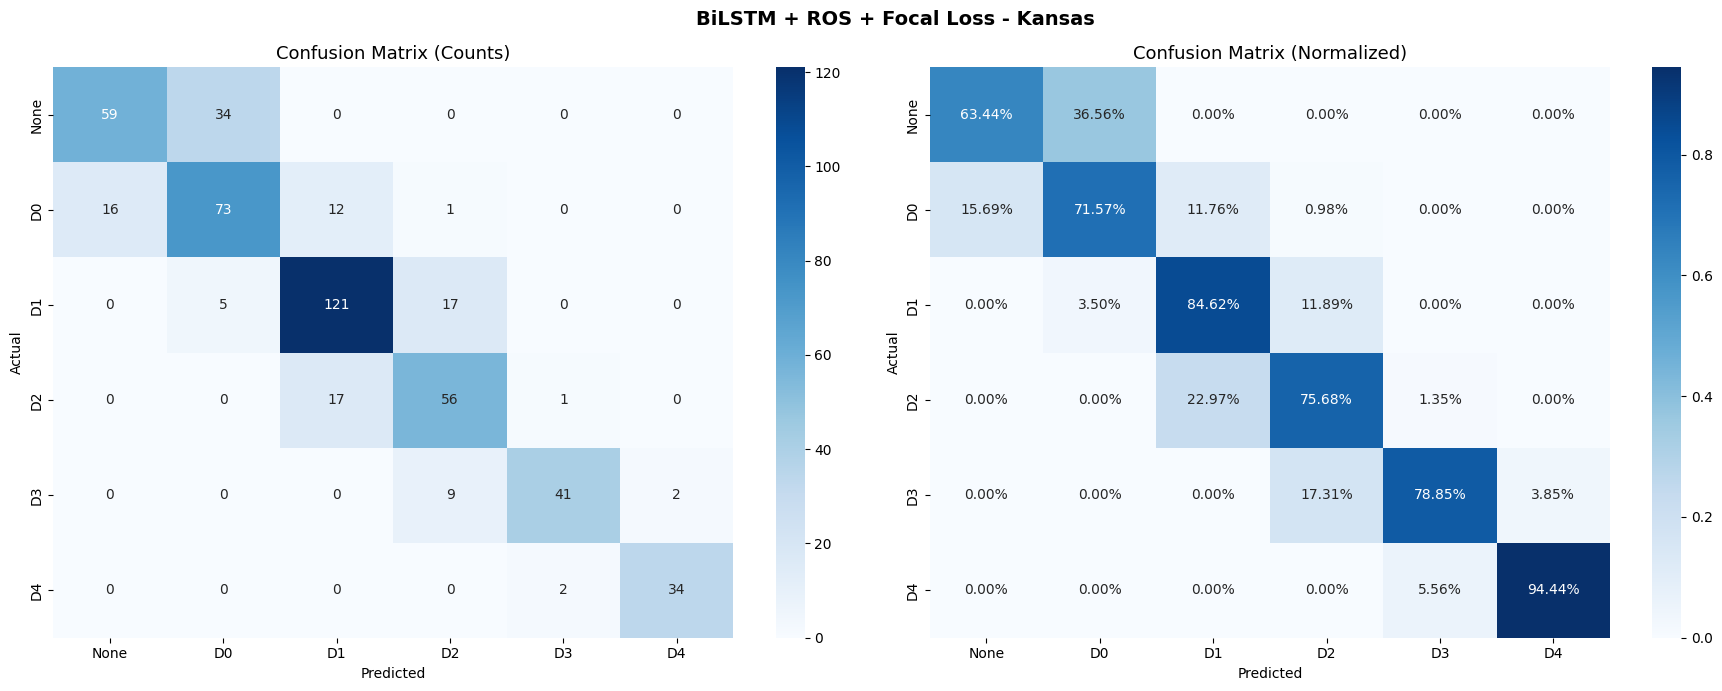

Saved plot to output_ROS/ROS_Kansas_confusion_matrix.png


In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(num_classes)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in range(num_classes)],
            yticklabels=[label_map[i] for i in range(num_classes)],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)  # Handle division by zero
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in range(num_classes)],
            yticklabels=[label_map[i] for i in range(num_classes)],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

fig.suptitle('BiLSTM + ROS + Focal Loss - Kansas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_confusion_matrix.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_confusion_matrix.png')

### 6.4 Per-Class F1 Score Visualization

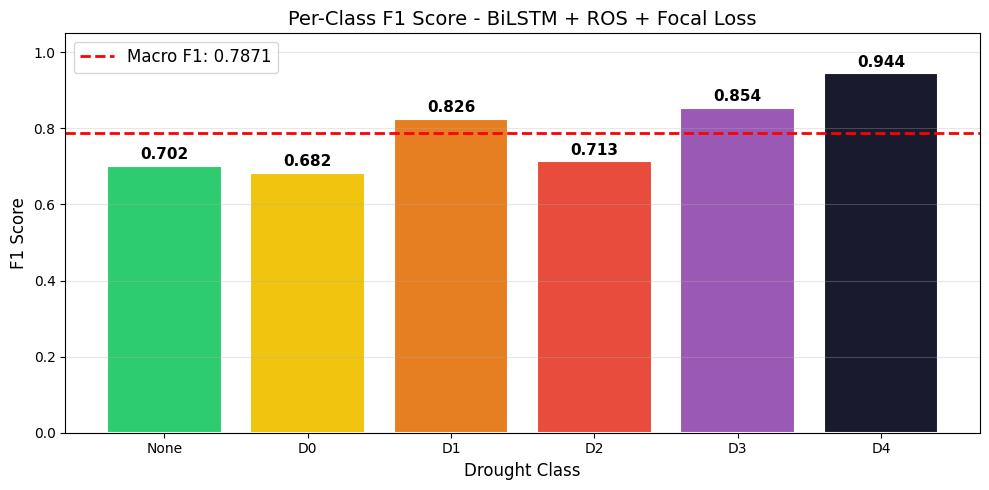

Saved plot to output_ROS/ROS_Kansas_per_class_f1.png


In [25]:
# Per-class F1 scores
per_class_f1 = f1_score(y_test, y_pred, labels=list(range(num_classes)), average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#1a1a2e']
bars = ax.bar([label_map[i] for i in range(num_classes)], per_class_f1,
              color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, f1_val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{f1_val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add macro F1 line
ax.axhline(y=macro_f1, color='red', linestyle='--', linewidth=2, label=f'Macro F1: {macro_f1:.4f}')

ax.set_title('Per-Class F1 Score - BiLSTM + ROS + Focal Loss', fontsize=14)
ax.set_xlabel('Drought Class', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/ROS_Kansas_per_class_f1.png', dpi=150)
plt.show()
print(f'Saved plot to {OUTPUT_FOLDER}/ROS_Kansas_per_class_f1.png')

### 6.5 Summary

In [26]:
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"Model:         BiLSTM (3 layers: 128-64-32 units)")
print(f"Balancing:     ROS (Random Over Sampling)")
print(f"Loss Function: Focal Loss (gamma=2.0) with class weights")
print(f"Seq Length:    {SEQ_LENGTH} months (1 year cycle)")
print(f"Split:         Temporal (Train: 2014-{TRAIN_END_YEAR}, Test: {TRAIN_END_YEAR+1}-2024)")
print(f"Batch Size:    {BATCH_SIZE}")
print(f"Epochs:        {len(history.history['loss'])} (of {EPOCHS} max)")
print(f"")
print(f"--- Results ---")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")
print(f"")
print(f"Per-class F1:")
for i in range(num_classes):
    print(f"  {label_map[i]:>4s}: {per_class_f1[i]:.4f}")
print("="*60)

# Save results to file
with open(f'{OUTPUT_FOLDER}/results_summary.txt', 'w') as f:
    f.write(f"Model: BiLSTM + ROS + Focal Loss\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n")
    f.write(f"Weighted F1: {weighted_f1:.4f}\n")
    f.write(f"\nPer-class F1:\n")
    for i in range(num_classes):
        f.write(f"  {label_map[i]}: {per_class_f1[i]:.4f}\n")
    f.write(f"\nClassification Report:\n")
    f.write(report)

print(f"\nResults saved to {OUTPUT_FOLDER}/results_summary.txt")


EXPERIMENT SUMMARY
Model:         BiLSTM (3 layers: 128-64-32 units)
Balancing:     ROS (Random Over Sampling)
Loss Function: Focal Loss (gamma=2.0) with class weights
Seq Length:    12 months (1 year cycle)
Split:         Temporal (Train: 2014-2021, Test: 2022-2024)
Batch Size:    32
Epochs:        106 (of 200 max)

--- Results ---
Accuracy:      0.7680
Macro F1:      0.7871
Weighted F1:   0.7685

Per-class F1:
  None: 0.7024
    D0: 0.6822
    D1: 0.8259
    D2: 0.7134
    D3: 0.8542
    D4: 0.9444

Results saved to output_ROS/results_summary.txt
